In [195]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

In [148]:
data_1 = np.concatenate((np.loadtxt('all_harmonics_output.txt'), 
                      np.loadtxt('2025_11_22_injections.txt'),
                      np.loadtxt('2025_11_28_injections.txt')))
data_1[:, 2] = 1
data_5 = np.loadtxt('injections_5_days.txt')
data_6 = np.loadtxt('injections_6_days.txt')
data_7 = np.loadtxt('injections_7_days.txt')
data_8 = np.loadtxt('injections_8_days.txt')
data_9 = np.loadtxt('injections_9_days.txt')
data_10 = np.loadtxt('injections_10_days.txt')
data_11 = np.loadtxt('injections_11_days.txt')
data_12 = np.loadtxt('injections_12_days.txt')
data_13 = np.loadtxt('injections_13_days.txt')
data_14 = np.loadtxt('injections_14_days.txt')
data_15 = np.loadtxt('injections_15_days.txt')
data_16 = np.loadtxt('injections_16_days.txt')
data_17 = np.loadtxt('injections_17_days.txt')
data_18 = np.loadtxt('injections_18_days.txt')
data_19 = np.loadtxt('injections_19_days.txt')
data_20 = np.loadtxt('injections_20_days.txt')

data = [data_1, #data_5, data_6, 
        #data_7, data_8, 
        #data_9,
         data_10, data_11, 
        data_12, data_13, data_14, data_15, data_16,
        data_17, data_18, data_19, data_20]

In [149]:
p_total = []
days = []

for datum in data:
    p = len(datum[datum[:, -1] > 0.]) / len(datum)
    print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
    p_total.append(p)
    days.append(datum[0, 2])

days = np.array(days)

1-day stack: 271967 injections, p(1) = 0.31
10-day stack: 2420 injections, p(10) = 0.37
11-day stack: 6969 injections, p(11) = 0.39
12-day stack: 16447 injections, p(12) = 0.40
13-day stack: 20070 injections, p(13) = 0.41
14-day stack: 12856 injections, p(14) = 0.40
15-day stack: 3022 injections, p(15) = 0.39
16-day stack: 6694 injections, p(16) = 0.41
17-day stack: 10131 injections, p(17) = 0.40
18-day stack: 9562 injections, p(18) = 0.42
19-day stack: 7979 injections, p(19) = 0.42
20-day stack: 2361 injections, p(20) = 0.41


Text(0, 0.5, 'p(N)')

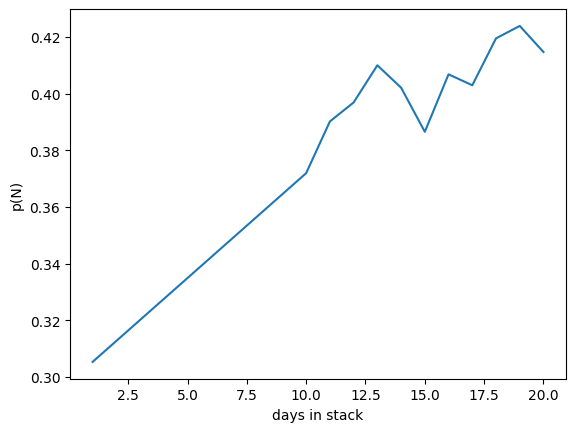

In [150]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

[0.02769647 0.07976723 0.02307355 0.02307355 0.0175144  0.02629797
 0.02560593 0.02152602 0.01691686 0.01691686 0.02008228 0.07600195] [0.01482749 0.0603281  0.01419251 0.01509094 0.01359847 0.01455565
 0.02366394 0.01115361 0.02831041 0.0100301  0.03113841 0.        ]


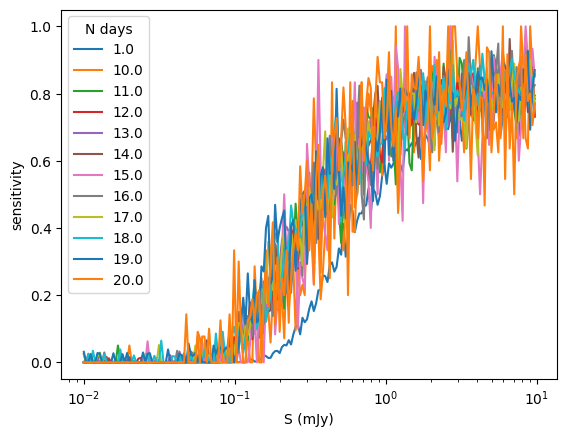

In [191]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_curve = np.zeros((len(data), len(S_bins) - 1))
S_10 = np.zeros(len(data))
S_1 = np.zeros(len(data))
S_err10_up = np.zeros(len(data))
S_err10_down = np.zeros(len(data))
S_err1_up = np.zeros(len(data))
S_err1_down = np.zeros(len(data))

for i in range(len(data)):
    _, S_sens, _ = au.get_sensitivity(
        data[i],
        *(S_idx, S_bins, S_dev)
    )

    plt.plot(S_bins[:-1], S_sens, label = days[i])

    S_curve[i] = S_sens
    S_smooth = gaussian_filter(S_sens, 5)
    S_10[i] = np.max(S_bins[np.where(S_smooth < 0.1)[0]])
    S_1[i] = np.max(S_bins[np.where(S_smooth < 0.01)[0]])
    p_10_idx = np.where(S_smooth < 0.1)[0][-1]
    local_std10 = np.std(S_sens[p_10_idx - 5:p_10_idx + 5])
    S_err10_up[i] = np.max(S_bins[np.where(S_smooth < 0.1 + local_std10)[0]])
    try:
        S_err10_down[i] = np.max(S_bins[np.where(S_smooth < 0.1 - local_std10)[0]])
    except:
        S_err10_down[i] = np.nan
    p_1_idx = np.where(S_smooth < 0.01)[0][-1]
    local_std1 = np.std(S_sens[p_1_idx - 5:p_1_idx + 5])
    S_err1_up[i] = np.max(S_bins[np.where(S_smooth < 0.01 + local_std1)[0]])
    try:
        S_err1_down[i] = np.max(S_bins[np.where(S_smooth < 0.01 - local_std1)[0]])
    except:
        S_err1_down[i] = np.nan

S_err10_down = S_10 - S_err10_down 
S_err10_up -= S_10 
S_err1_down = S_1 - S_err1_down 
S_err1_up -= S_1

# mask10 = np.isnan(S_err10_down) & (S_err10_down < 0.)
# S_err10_down[mask10] = S_10[mask10]
# mask1 = np.isnan(S_err1_down) & (S_err1_down < 0.)
# S_err10_down[mask1] = S_10[mask1]
print(S_err10_up, S_err1_up)

plt.xlabel('S (mJy)')
plt.ylabel('sensitivity')
plt.legend(title = 'N days')
plt.xscale('log')

([<matplotlib.axis.XTick at 0x7f6f07f8e350>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20')])

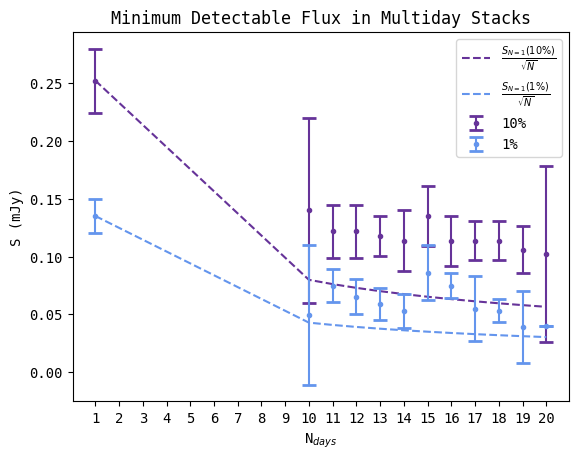

In [200]:
plt.errorbar(days, S_10, yerr = S_err10_up, label = '10%', color = 'rebeccapurple',
             fmt = '.', capsize=5, capthick=2)
plt.plot(days, S_10[0] / np.sqrt(days), '--', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{\sqrt{N}}$')
plt.errorbar(days, S_1, yerr = S_err1_up, label = '1%', color = 'cornflowerblue',
             fmt = '.', capsize=5, capthick=2)
plt.plot(days, S_1[0] / np.sqrt(days), '--', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{\sqrt{N}}$')
plt.xlabel(r'N$_{days}$')
plt.ylabel('S (mJy)')
plt.legend()
plt.title('Minimum Detectable Flux in Multiday Stacks')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]) 

In [189]:
print(S_err10_down)

[0.02495734        nan 0.02288868 0.01939713 0.01873536 0.02449979
 0.02914333 0.01809617 0.01809617 0.01809617 0.03848058        nan]
